# 35 — Layered-driver implosion mechanics

This workbook starts the mechanical core of the Roman reference design. It treats the target as three concentric material regions:

1. a **filled central sphere** of the reaction fuel being compressed;
2. a surrounding hot $p+{}^{15}$N driver containing the unresolved DT vein network;
3. an inert outer tamper, provisionally represented by lead density.

The central sphere is not a hollow piston. Its surface is the inner moving boundary of the hot driver chamber. The tamper is the outer moving boundary. Driver pressure therefore accelerates the central fuel inward and the tamper outward.

The notebook is a **zero-dimensional spherical mechanics model**, not yet a reference target. It asks how an explicitly stated heat-release pulse is converted into pressure, impulse, cold compression, outward tamper motion, and residual driver heat.

In [1]:
from dataclasses import asdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from cno_sweep.layered_driver import evolve_layered_pressure_pulse
from cno_sweep.n15_pusher import additive_volume_density

pd.set_option("display.precision", 6)
Q_N15_MEV = 4.966

## Equations being integrated

The driver volume is

$$V_d=\frac{4\pi}{3}(R_o^3-R_i^3),$$

and its zero-D ideal-plasma pressure is $P_d=(\gamma_d-1)U_d/V_d$. The driver energy evolves as

$$\dot U_d=\dot Q_{N15}+\dot Q_{DT,\alpha}+\eta_{DT,n}\dot Q_{DT,n}-P_d\dot V_d.$$

There is no unspecified pusher-to-core coupling factor. Pressure acts directly on both boundaries:

$$M_{i,\mathrm{eff}}\ddot R_i=4\pi R_i^2(P_c-P_d),$$

$$M_{o,\mathrm{eff}}\ddot R_o=4\pi R_o^2P_d.$$

The filled core has homologous velocity, so its radial kinetic energy is $3M_c\dot R_i^2/10$ and its effective moving mass is $3M_c/5$. Half the driver mass is provisionally assigned to each boundary. The tamper is a lumped outer shell.

Before deliberate heating, the core resistance is a zero-temperature electron cold curve. A constant ambient counterpressure is subtracted so the condensed initial state is stationary. Optional core preheat adds an ideal-gas pressure term at an explicitly chosen compression. This is adequate for exposing timing penalties, but the common-EOS workbook must replace the approximate material cold curve and hot-core EOS before final sizing.

## Mechanical upper-bound input point

We use Constantine ($^{13}$C+$\alpha$) only as a representative central material. The initial one-metre core is a scale normalization: at fixed composition, density, mass ratios, and dimensionless pulse duration, radii and times scale linearly and masses scale as $R_0^3$.

The point deliberately assigns one loaded and completely burned N15 per initial Constantine fuel unit. Thus all 4.966 MeV of the terminal Trajan reaction is available to this one event. That is a mechanical upper bound, not a globally legal allocation across five recipes. The later ledger/allocation workbooks must divide the one net N15 burn among the complete cycle.

In [2]:
carbon_density_kg_m3 = 2267.0
helium_density_kg_m3 = 125.0
constantine_density_kg_m3 = 17.0 / (13.0 / carbon_density_kg_m3 + 4.0 / helium_density_kg_m3)
driver_proton_ratio = 4.0
driver_density_kg_m3 = additive_volume_density(driver_proton_ratio)

inputs = {
    "event_id": "constantine-normalized-cold-bound",
    "initial_core_radius_m": 1.0,
    "initial_core_density_kg_m3": constantine_density_kg_m3,
    "initial_abundances": {"c13": 1.0, "he4": 1.0},
    "driver_n15_loaded_per_core_unit": 1.0,
    "driver_proton_ratio": driver_proton_ratio,
    "n15_burn_fraction": 1.0,
    "dt_pairs_loaded_per_core_unit": 0.0,
    "dt_burn_fraction": 0.0,
    "dt_neutron_deposition_fraction": 0.0,
    "driver_density_kg_m3": driver_density_kg_m3,
    "tamper_to_driver_mass_ratio": 4.0,
    "tamper_density_kg_m3": 11340.0,
    "burn_duration_over_characteristic_time": 0.1,
}
display(pd.DataFrame([
    {"input": "C13+He initial density", "value": constantine_density_kg_m3, "units": "kg/m^3"},
    {"input": "p:N15 number ratio", "value": driver_proton_ratio, "units": "ratio"},
    {"input": "p+N15 additive density", "value": driver_density_kg_m3, "units": "kg/m^3"},
    {"input": "tamper:driver mass ratio", "value": 4.0, "units": "ratio"},
    {"input": "tamper density", "value": 11340.0, "units": "kg/m^3"},
    {"input": "pulse duration / characteristic time", "value": 0.1, "units": "ratio"},
]))

,input,value,units
0,C13+He initial density,450.516693,kg/m^3
1,p:N15 number ratio,4.000000,ratio
2,p+N15 additive density,253.125664,kg/m^3
3,tamper:driver mass ratio,4.000000,ratio
4,tamper density,11340.000000,kg/m^3
5,pulse duration / characteristic time,0.100000,ratio


In [3]:
reference = evolve_layered_pressure_pulse(**inputs)
geometry = pd.DataFrame([
    {"quantity": "central fuel R0", "value": reference.initial_core_radius_m, "units": "m"},
    {"quantity": "active-driver thickness", "value": reference.initial_driver_thickness_m, "units": "m"},
    {"quantity": "tamper thickness", "value": reference.initial_tamper_thickness_m, "units": "m"},
    {"quantity": "complete target Rout,0", "value": reference.initial_physical_outer_radius_m, "units": "m"},
    {"quantity": "central fuel mass", "value": reference.core_mass_kg, "units": "kg"},
    {"quantity": "active-driver mass", "value": reference.driver_mass_kg, "units": "kg"},
    {"quantity": "tamper mass", "value": reference.tamper_mass_kg, "units": "kg"},
])
dynamics = pd.DataFrame([
    {"quantity": "deposited driver energy", "value": reference.driver_energy_mev_per_core_unit, "units": "MeV/core unit"},
    {"quantity": "characteristic time", "value": reference.characteristic_time_s, "units": "s"},
    {"quantity": "pulse duration", "value": reference.burn_duration_s, "units": "s"},
    {"quantity": "peak-compression time", "value": reference.peak_time_s, "units": "s"},
    {"quantity": "peak compression rho/rho0", "value": reference.peak_compression_ratio, "units": "ratio"},
    {"quantity": "peak core Rf", "value": reference.peak_core_radius_m, "units": "m"},
    {"quantity": "peak driver pressure", "value": reference.peak_driver_pressure_pa, "units": "Pa"},
    {"quantity": "maximum inward surface speed", "value": reference.inward_surface_velocity_m_s, "units": "m/s"},
    {"quantity": "maximum outward surface speed", "value": reference.outward_surface_velocity_m_s, "units": "m/s"},
])
display(geometry)
display(dynamics)

,quantity,value,units
0,central fuel R0,1.000000,m
1,active-driver thickness,0.440517,m
2,tamper thickness,0.027983,m
3,"complete target Rout,0",1.468501,m
4,central fuel mass,1887.119911,kg
5,active-driver mass,2109.134019,kg
6,tamper mass,8436.536075,kg


,quantity,value,units
0,deposited driver energy,4.966000e+00,MeV/core unit
1,characteristic time,1.433785e-07,s
2,pulse duration,1.433785e-08,s
3,peak-compression time,4.429568e-07,s
4,peak compression rho/rho0,2.911136e+06,ratio
5,peak core Rf,7.003458e-03,m
6,peak driver pressure,4.240448e+15,Pa
7,maximum inward surface speed,2.814025e+06,m/s
8,maximum outward surface speed,2.319379e+06,m/s


## Time history and energy conservation

The half-sine heat pulse raises driver pressure. The inner surface accelerates inward; the outer driver boundary and tamper accelerate outward. Peak compression is the first inner-surface stagnation.

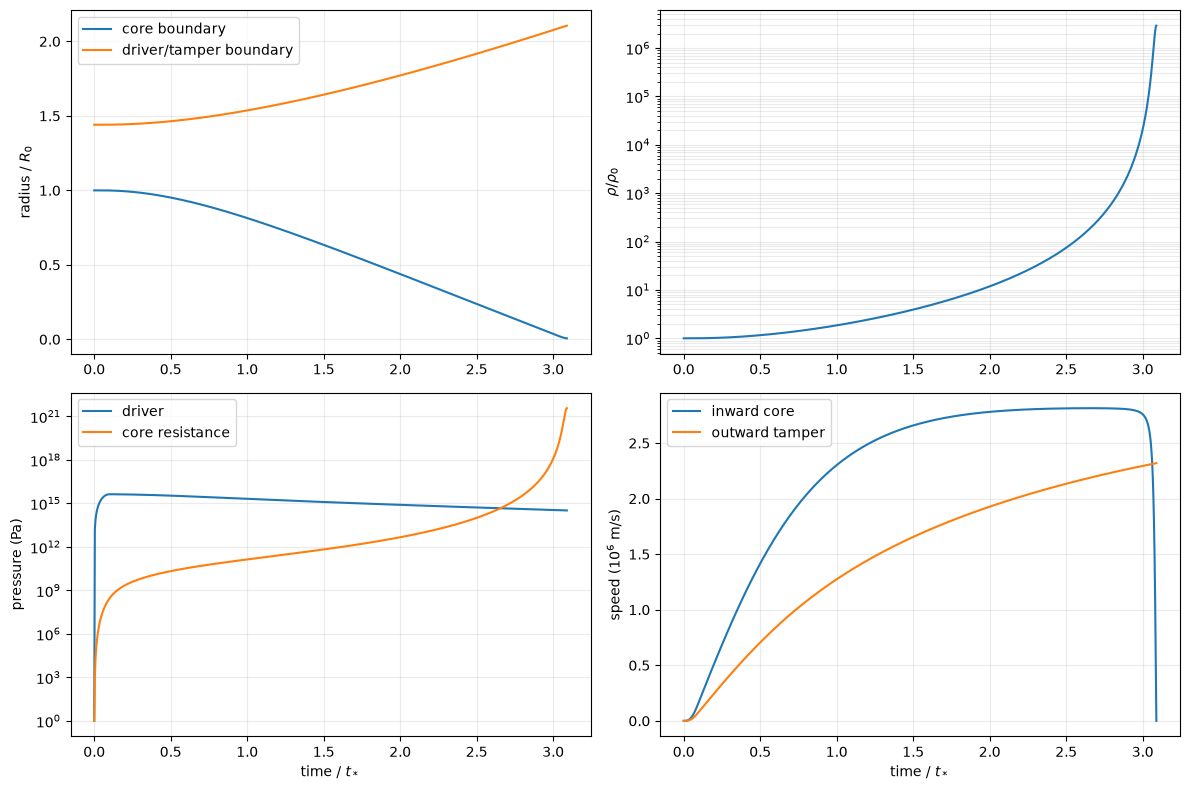

,destination at peak compression,MeV/core unit,fraction of injected
0,cold core compression,8.106642e-01,1.632429e-01
1,inward kinetic (zero at stagnation),3.281433e-19,6.607799e-20
2,outward tamper/driver kinetic,2.383518e+00,4.799673e-01
3,residual driver internal energy,1.771818e+00,3.567898e-01
4,hot core internal energy,0.000000e+00,0.000000e+00


Energy residual: 2.060e-12


In [4]:
trace = reference.trace
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
x = trace["time_over_characteristic"]
axes[0, 0].plot(x, trace["core_radius_m"] / reference.initial_core_radius_m, label="core boundary")
axes[0, 0].plot(x, trace["driver_outer_radius_m"] / reference.initial_core_radius_m, label="driver/tamper boundary")
axes[0, 0].set(ylabel=r"radius / $R_0$")
axes[0, 0].legend()
axes[0, 1].semilogy(x, trace["compression_ratio"])
axes[0, 1].set(ylabel=r"$\rho/\rho_0$")
axes[1, 0].semilogy(x, np.maximum(trace["driver_pressure_pa"], 1.0), label="driver")
axes[1, 0].semilogy(x, np.maximum(trace["core_pressure_pa"], 1.0), label="core resistance")
axes[1, 0].set(xlabel=r"time / $t_*$", ylabel="pressure (Pa)")
axes[1, 0].legend()
axes[1, 1].plot(x, trace["inward_surface_velocity_m_s"] / 1e6, label="inward core")
axes[1, 1].plot(x, trace["outward_surface_velocity_m_s"] / 1e6, label="outward tamper")
axes[1, 1].set(xlabel=r"time / $t_*$", ylabel="speed (10$^6$ m/s)")
axes[1, 1].legend()
for ax in axes.flat:
    ax.grid(True, which="both", alpha=0.25)
plt.tight_layout()
plt.show()

energy_ledger = pd.DataFrame([
    {"destination at peak compression": "cold core compression", "MeV/core unit": reference.cold_core_energy_mev_per_core_unit},
    {"destination at peak compression": "inward kinetic (zero at stagnation)", "MeV/core unit": reference.inward_kinetic_mev_per_core_unit},
    {"destination at peak compression": "outward tamper/driver kinetic", "MeV/core unit": reference.outward_kinetic_mev_per_core_unit},
    {"destination at peak compression": "residual driver internal energy", "MeV/core unit": reference.residual_driver_mev_per_core_unit},
    {"destination at peak compression": "hot core internal energy", "MeV/core unit": reference.hot_core_mev_per_core_unit},
])
energy_ledger["fraction of injected"] = energy_ledger["MeV/core unit"] / reference.injected_mev_per_core_unit
display(energy_ledger)
print(f"Energy residual: {reference.energy_residual_fraction:.3e}")
assert abs(reference.energy_residual_fraction) < 1e-7

## What does a 4:1 tamper ratio buy?

For equal and opposite scalar impulses on two planarized boundaries, $K=I^2/(2M)$ gives

$$f_{K,\mathrm{in}}=\frac{M_{o,\mathrm{eff}}}{M_{i,\mathrm{eff}}+M_{o,\mathrm{eff}}}.$$

Thus 90% requires a 9:1 ratio of **effective moving masses**, not generally a 4:1 tamper:driver loading. The spherical integration also contains changing areas, cold-core resistance, and driver internal energy, so the useful cold-compression fraction is not identical to this two-mass limit.

,tamper/driver mass,equal-impulse inward fraction,useful cold-compression fraction,outward kinetic fraction at stagnation,residual-driver fraction,peak compression,tamper thickness / R0
0,0.25,0.419735,0.063118,0.883619,0.053263,6.345854e+05,0.001781
1,1.00,0.591286,0.100010,0.766416,0.133574,1.313396e+06,0.007098
2,2.00,0.706845,0.130356,0.642561,0.227083,2.013259e+06,0.014126
3,4.00,0.812738,0.163243,0.479967,0.356790,2.911136e+06,0.027983
4,9.00,0.901598,0.195557,0.290959,0.513484,3.933357e+06,0.061527
5,20.00,0.951857,0.216142,0.155167,0.628691,4.657012e+06,0.130476
6,100.00,0.989789,0.232955,0.035225,0.731820,5.290178e+06,0.510755


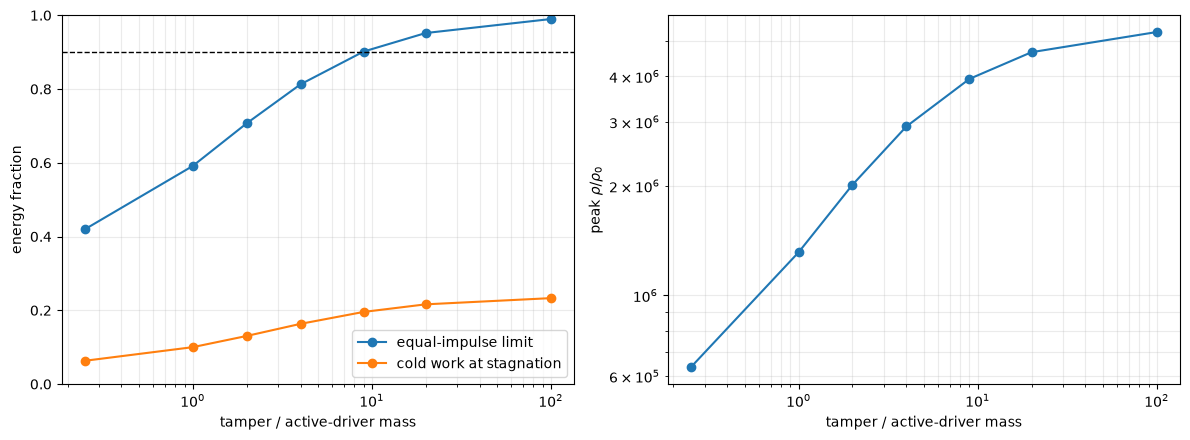

In [5]:
tamper_rows = []
for ratio in [0.25, 1.0, 2.0, 4.0, 9.0, 20.0, 100.0]:
    result = evolve_layered_pressure_pulse(**{**inputs, "event_id": f"tamper-{ratio:g}", "tamper_to_driver_mass_ratio": ratio})
    tamper_rows.append({
        "tamper/driver mass": ratio,
        "equal-impulse inward fraction": result.equal_impulse_inward_fraction,
        "useful cold-compression fraction": result.useful_cold_compression_fraction,
        "outward kinetic fraction at stagnation": result.outward_kinetic_mev_per_core_unit / result.injected_mev_per_core_unit,
        "residual-driver fraction": result.residual_driver_mev_per_core_unit / result.injected_mev_per_core_unit,
        "peak compression": result.peak_compression_ratio,
        "tamper thickness / R0": result.initial_tamper_thickness_m / result.initial_core_radius_m,
    })
tamper_table = pd.DataFrame(tamper_rows)
display(tamper_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].semilogx(tamper_table["tamper/driver mass"], tamper_table["equal-impulse inward fraction"], "o-", label="equal-impulse limit")
axes[0].semilogx(tamper_table["tamper/driver mass"], tamper_table["useful cold-compression fraction"], "o-", label="cold work at stagnation")
axes[0].axhline(0.9, color="black", linestyle="--", linewidth=1)
axes[0].set(xlabel="tamper / active-driver mass", ylabel="energy fraction", ylim=(0, 1))
axes[0].legend()
axes[1].loglog(tamper_table["tamper/driver mass"], tamper_table["peak compression"], "o-")
axes[1].set(xlabel="tamper / active-driver mass", ylabel=r"peak $\rho/\rho_0$")
for ax in axes:
    ax.grid(True, which="both", alpha=0.25)
plt.tight_layout()
plt.show()

## Does finite mantle ignition time matter mechanically?

The vein workbook must eventually supply an absolute heat-release history. Here the same total deposited energy is spread over a half-sine pulse whose duration is measured against $t_*=R_0/\sqrt{2E_d/M_{i,\mathrm{eff}}}$.

In [6]:
pulse_rows = []
for duration_ratio in [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]:
    result = evolve_layered_pressure_pulse(**{**inputs, "event_id": f"pulse-{duration_ratio:g}", "burn_duration_over_characteristic_time": duration_ratio})
    pulse_rows.append({
        "pulse/t*": duration_ratio,
        "peak-time/t*": result.peak_time_s / result.characteristic_time_s,
        "peak compression": result.peak_compression_ratio,
        "cold-compression fraction": result.useful_cold_compression_fraction,
    })
pulse_table = pd.DataFrame(pulse_rows)
display(pulse_table)

,pulse/t*,peak-time/t*,peak compression,cold-compression fraction
0,0.01,3.043881,2.913841e+06,0.163335
1,0.03,3.053925,2.913622e+06,0.163327
2,0.10,3.089422,2.911136e+06,0.163243
3,0.30,3.193572,2.889787e+06,0.162518
4,1.00,3.581527,2.678840e+06,0.155220
5,3.00,4.723289,1.737709e+06,0.119040


## Preheat timing: why mixed N15 can spoil compression

To isolate the timing effect, keep the total 4.966-MeV Trajan budget fixed. A stated fraction is removed from the outer driver pulse and deposited as central-fuel heat when the core reaches a chosen compression. The added material mass, detailed mixed-N15 reaction rate, and radiation are not yet included, so this is a pressure-feedback experiment rather than an optimized mixture.

Early heat is subsequently adiabatically compressed and raises outward core pressure for much of the trajectory. Late heat has far less time to oppose the incoming motion.

,Trajan energy moved into core,preheat trigger compression,peak compression,"peak core T, classical screen (keV)",preheat actually triggered
0,0.000,10.0,2.911136e+06,0.000000,True
1,0.000,100.0,2.911136e+06,0.000000,True
2,0.000,1000.0,2.911136e+06,0.000000,True
3,0.000,10000.0,2.911136e+06,0.000000,True
4,0.000,100000.0,2.911136e+06,0.000000,True
5,0.000,500000.0,2.911136e+06,0.000000,True
6,0.001,10.0,1.978200e+04,52.170968,True
7,0.001,100.0,1.621354e+05,45.691346,True
8,0.001,1000.0,8.368010e+05,29.398845,True
9,0.001,10000.0,2.001031e+06,11.326212,True


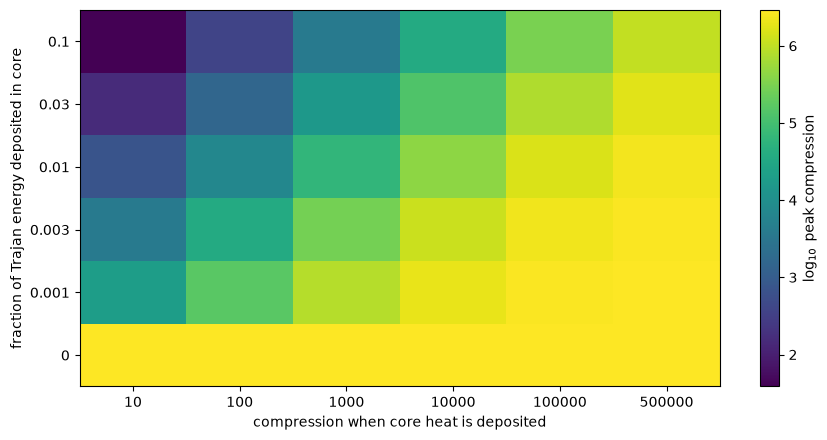

In [7]:
mixed_fractions = [0.0, 0.001, 0.003, 0.01, 0.03, 0.10]
preheat_triggers = [10.0, 1e2, 1e3, 1e4, 1e5, 5e5]
preheat_rows = []
for mixed_fraction in mixed_fractions:
    for trigger in preheat_triggers:
        kwargs = {
            **inputs,
            "event_id": f"preheat-{mixed_fraction:g}-{trigger:g}",
            "n15_burn_fraction": 1.0 - mixed_fraction,
            "core_preheat_mev_per_core_unit": mixed_fraction * Q_N15_MEV,
            "preheat_compression_ratio": trigger,
        }
        result = evolve_layered_pressure_pulse(**kwargs)
        preheat_rows.append({
            "Trajan energy moved into core": mixed_fraction,
            "preheat trigger compression": trigger,
            "peak compression": result.peak_compression_ratio,
            "peak core T, classical screen (keV)": result.peak_core_temperature_keV,
            "preheat actually triggered": result.core_preheat_mev_per_core_unit > 0.0 or mixed_fraction == 0.0,
        })
preheat_table = pd.DataFrame(preheat_rows)
display(preheat_table)

heatmap = preheat_table.pivot(index="Trajan energy moved into core", columns="preheat trigger compression", values="peak compression")
fig, ax = plt.subplots(figsize=(9, 4.5))
image = ax.imshow(np.log10(heatmap.values), aspect="auto", origin="lower", cmap="viridis")
ax.set_xticks(range(len(heatmap.columns)), [f"{value:g}" for value in heatmap.columns])
ax.set_yticks(range(len(heatmap.index)), [f"{value:g}" for value in heatmap.index])
ax.set(xlabel="compression when core heat is deposited", ylabel="fraction of Trajan energy deposited in core")
fig.colorbar(image, ax=ax, label=r"$\log_{10}$ peak compression")
plt.tight_layout()
plt.show()

## Explicit DT supplement—not yet a fuel-cycle allowance

DT veins add their own inertia and deposited energy. The lower bracket below credits only the 3.52-MeV alpha; the upper bracket also deposits the DT-neutron energy during the useful pulse. The mixture bulk density is held at the p+N15 value in this small-loading screen. The real point must use a composition-dependent density, time-dependent neutron transport, and the D/T ledger.

In [8]:
dt_rows = []
for dt_pairs in [0.0, 0.01, 0.03, 0.10]:
    for neutron_deposition in [0.0, 1.0]:
        result = evolve_layered_pressure_pulse(**{
            **inputs,
            "event_id": f"dt-{dt_pairs:g}-{neutron_deposition:g}",
            "dt_pairs_loaded_per_core_unit": dt_pairs,
            "dt_burn_fraction": 1.0 if dt_pairs else 0.0,
            "dt_neutron_deposition_fraction": neutron_deposition,
        })
        dt_rows.append({
            "DT pairs loaded and burned/core unit": dt_pairs,
            "DT-neutron deposition": neutron_deposition,
            "DT deposited MeV/core unit": result.dt_energy_mev_per_core_unit,
            "peak compression": result.peak_compression_ratio,
            "driver/core mass": result.driver_to_core_mass_ratio,
        })
dt_table = pd.DataFrame(dt_rows)
display(dt_table)

,DT pairs loaded and burned/core unit,DT-neutron deposition,DT deposited MeV/core unit,peak compression,driver/core mass
0,0.00,0.0,0.00000,2.911136e+06,1.117647
1,0.00,1.0,0.00000,2.911136e+06,1.117647
2,0.01,0.0,0.03520,2.937204e+06,1.120588
3,0.01,1.0,0.17589,3.075309e+06,1.120588
4,0.03,0.0,0.10560,2.989381e+06,1.126471
5,0.03,1.0,0.52767,3.413950e+06,1.126471
6,0.10,0.0,0.35200,3.172350e+06,1.147059
7,0.10,1.0,1.75890,4.703691e+06,1.147059


## Scale invariance of this mechanical kernel

Changing $R_0$ alone does not create free compression. It scales all layer thicknesses and the pulse/implosion time, while leaving the normalized compression and energy per central unit unchanged. Larger targets become useful when nuclear burn, ignition propagation, stopping, and neutron transport introduce their own physical times and columns.

In [9]:
scale_rows = []
for radius in [0.1, 1.0, 10.0, 100.0]:
    result = evolve_layered_pressure_pulse(**{**inputs, "event_id": f"scale-{radius:g}", "initial_core_radius_m": radius})
    scale_rows.append({
        "R0 (m)": radius,
        "Rout,0 (m)": result.initial_physical_outer_radius_m,
        "Rf (m)": result.peak_core_radius_m,
        "peak compression": result.peak_compression_ratio,
        "peak time (s)": result.peak_time_s,
        "total mass (kg)": result.core_mass_kg + result.driver_mass_kg + result.tamper_mass_kg,
    })
display(pd.DataFrame(scale_rows))

,R0 (m),"Rout,0 (m)",Rf (m),peak compression,peak time (s),total mass (kg)
0,0.1,0.146850,0.000700,2.911136e+06,4.429568e-08,1.243279e+01
1,1.0,1.468501,0.007003,2.911136e+06,4.429568e-07,1.243279e+04
2,10.0,14.685005,0.070035,2.911136e+06,4.429568e-06,1.243279e+07
3,100.0,146.850053,0.700346,2.911136e+06,4.429568e-05,1.243279e+10


## What this says—and what it does not

For the normalized cold upper bound, the model produces the complete radii, masses, pressure pulse, velocities, compression, and energy partition printed above. The important qualitative findings are:

- the tamper really does improve inward compression, but 4:1 tamper:driver mass is not automatically 90% inward energy;
- even with a massive tamper, pressure-chamber expansion leaves substantial energy in outward motion and residual hot driver plasma;
- finite mantle ignition time matters when it becomes comparable to the mechanical time;
- moving even a small share of the energy into the core too early can reduce compression by orders of magnitude; delayed heating is therefore a first-order design variable, not a detail;
- geometric scale cancels out of the normalized mechanics and must be selected by burn, propagation, stopping, and neutron constraints.

Still absent are the DT-vein propagation solution, p+N15 burn history, bremsstrahlung/opacity, shocks and entropy generation, material-strength failure, instability/mixing, a validated lead EOS, and the hot central reaction. Consequently the millions-fold cold compression shown here is a **mechanical upper bound**, not a reference-design claim.

The next useful coupling is clear: workbook 30 must provide a likely and conservative driver heat-release duration and deposition history. This workbook can then convert those histories directly into achieved compression without inventing a scalar coupling efficiency.